In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from scipy import stats
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv("./input/train.csv")
test = pd.read_csv("./input/test.csv")

display(train.head(n=1))

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


In [3]:
train.shape

(1460, 81)

In [4]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
for i in train.columns:
    print(i,":",train.dtypes[i])

Id : int64
MSSubClass : int64
MSZoning : object
LotFrontage : float64
LotArea : int64
Street : object
Alley : object
LotShape : object
LandContour : object
Utilities : object
LotConfig : object
LandSlope : object
Neighborhood : object
Condition1 : object
Condition2 : object
BldgType : object
HouseStyle : object
OverallQual : int64
OverallCond : int64
YearBuilt : int64
YearRemodAdd : int64
RoofStyle : object
RoofMatl : object
Exterior1st : object
Exterior2nd : object
MasVnrType : object
MasVnrArea : float64
ExterQual : object
ExterCond : object
Foundation : object
BsmtQual : object
BsmtCond : object
BsmtExposure : object
BsmtFinType1 : object
BsmtFinSF1 : int64
BsmtFinType2 : object
BsmtFinSF2 : int64
BsmtUnfSF : int64
TotalBsmtSF : int64
Heating : object
HeatingQC : object
CentralAir : object
Electrical : object
1stFlrSF : int64
2ndFlrSF : int64
LowQualFinSF : int64
GrLivArea : int64
BsmtFullBath : int64
BsmtHalfBath : int64
FullBath : int64
HalfBath : int64
BedroomAbvGr : int64
Kitche

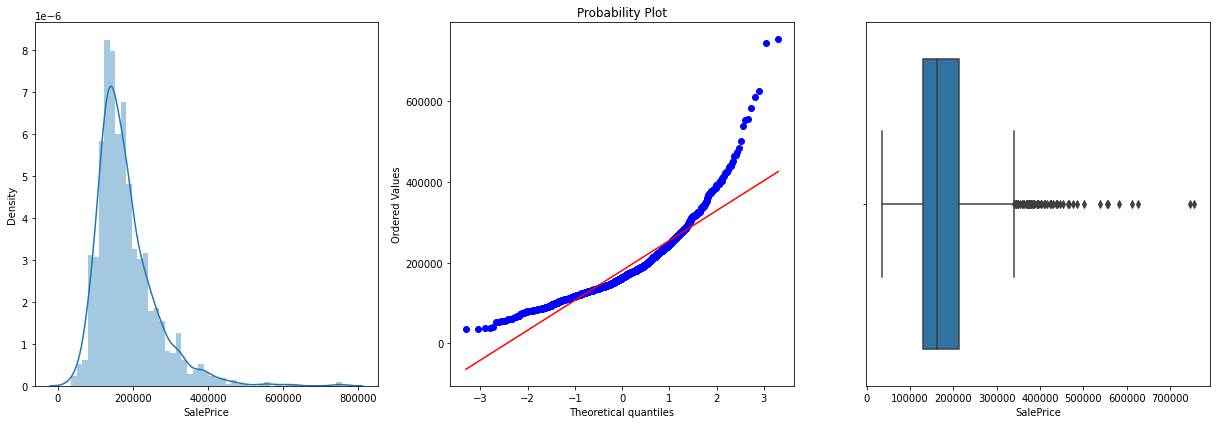

In [8]:
plt.figure(figsize=(17,6))
plt.subplot(131)
sns.distplot(train["SalePrice"])

plt.subplot(132)
stats.probplot(train["SalePrice"],plot=plt)

plt.subplot(133)
sns.boxplot(train["SalePrice"])
plt.tight_layout()
plt.show()

In [19]:
normalized_price = np.log1p(train["SalePrice"])
print(normalized_price)

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64


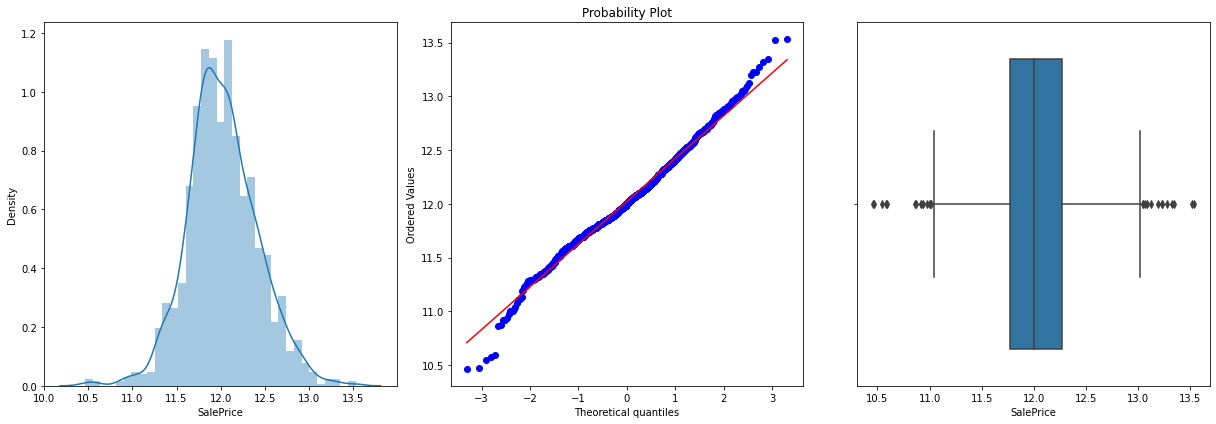

In [20]:
plt.figure(figsize=(17,6))
plt.subplot(131)
sns.distplot(normalized_price)

plt.subplot(132)
stats.probplot(normalized_price,plot=plt)

plt.subplot(133)
sns.boxplot(normalized_price)
plt.tight_layout()
plt.show()

In [15]:
for i in numerical_features:
    print(train[i].head(5))

0    1
1    2
2    3
3    4
4    5
Name: Id, dtype: int64
0    60
1    20
2    60
3    70
4    60
Name: MSSubClass, dtype: int64
0    65.0
1    80.0
2    68.0
3    60.0
4    84.0
Name: LotFrontage, dtype: float64
0     8450
1     9600
2    11250
3     9550
4    14260
Name: LotArea, dtype: int64
0    7
1    6
2    7
3    7
4    8
Name: OverallQual, dtype: int64
0    5
1    8
2    5
3    5
4    5
Name: OverallCond, dtype: int64
0    2003
1    1976
2    2001
3    1915
4    2000
Name: YearBuilt, dtype: int64
0    2003
1    1976
2    2002
3    1970
4    2000
Name: YearRemodAdd, dtype: int64
0    196.0
1      0.0
2    162.0
3      0.0
4    350.0
Name: MasVnrArea, dtype: float64
0    706
1    978
2    486
3    216
4    655
Name: BsmtFinSF1, dtype: int64
0    0
1    0
2    0
3    0
4    0
Name: BsmtFinSF2, dtype: int64
0    150
1    284
2    434
3    540
4    490
Name: BsmtUnfSF, dtype: int64
0     856
1    1262
2     920
3     756
4    1145
Name: TotalBsmtSF, dtype: int64
0     856
1    1262


In [16]:
train["MSSubClass"] = train["MSSubClass"].astype('str')

In [17]:
numerical_features = []
categorical_features = []
for f in train.columns:
    if train.dtypes[f] == 'object':
        categorical_features.append(f)
    else:
        numerical_features.append(f)

In [18]:
for i in categorical_features:
    print(train[i].head(5))

0    60
1    20
2    60
3    70
4    60
Name: MSSubClass, dtype: object
0    RL
1    RL
2    RL
3    RL
4    RL
Name: MSZoning, dtype: object
0    Pave
1    Pave
2    Pave
3    Pave
4    Pave
Name: Street, dtype: object
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Alley, dtype: object
0    Reg
1    Reg
2    IR1
3    IR1
4    IR1
Name: LotShape, dtype: object
0    Lvl
1    Lvl
2    Lvl
3    Lvl
4    Lvl
Name: LandContour, dtype: object
0    AllPub
1    AllPub
2    AllPub
3    AllPub
4    AllPub
Name: Utilities, dtype: object
0    Inside
1       FR2
2    Inside
3    Corner
4       FR2
Name: LotConfig, dtype: object
0    Gtl
1    Gtl
2    Gtl
3    Gtl
4    Gtl
Name: LandSlope, dtype: object
0    CollgCr
1    Veenker
2    CollgCr
3    Crawfor
4    NoRidge
Name: Neighborhood, dtype: object
0     Norm
1    Feedr
2     Norm
3     Norm
4     Norm
Name: Condition1, dtype: object
0    Norm
1    Norm
2    Norm
3    Norm
4    Norm
Name: Condition2, dtype: object
0    1Fam
1    1Fam
2    1Fam

In [40]:
len(numerical_features)

37

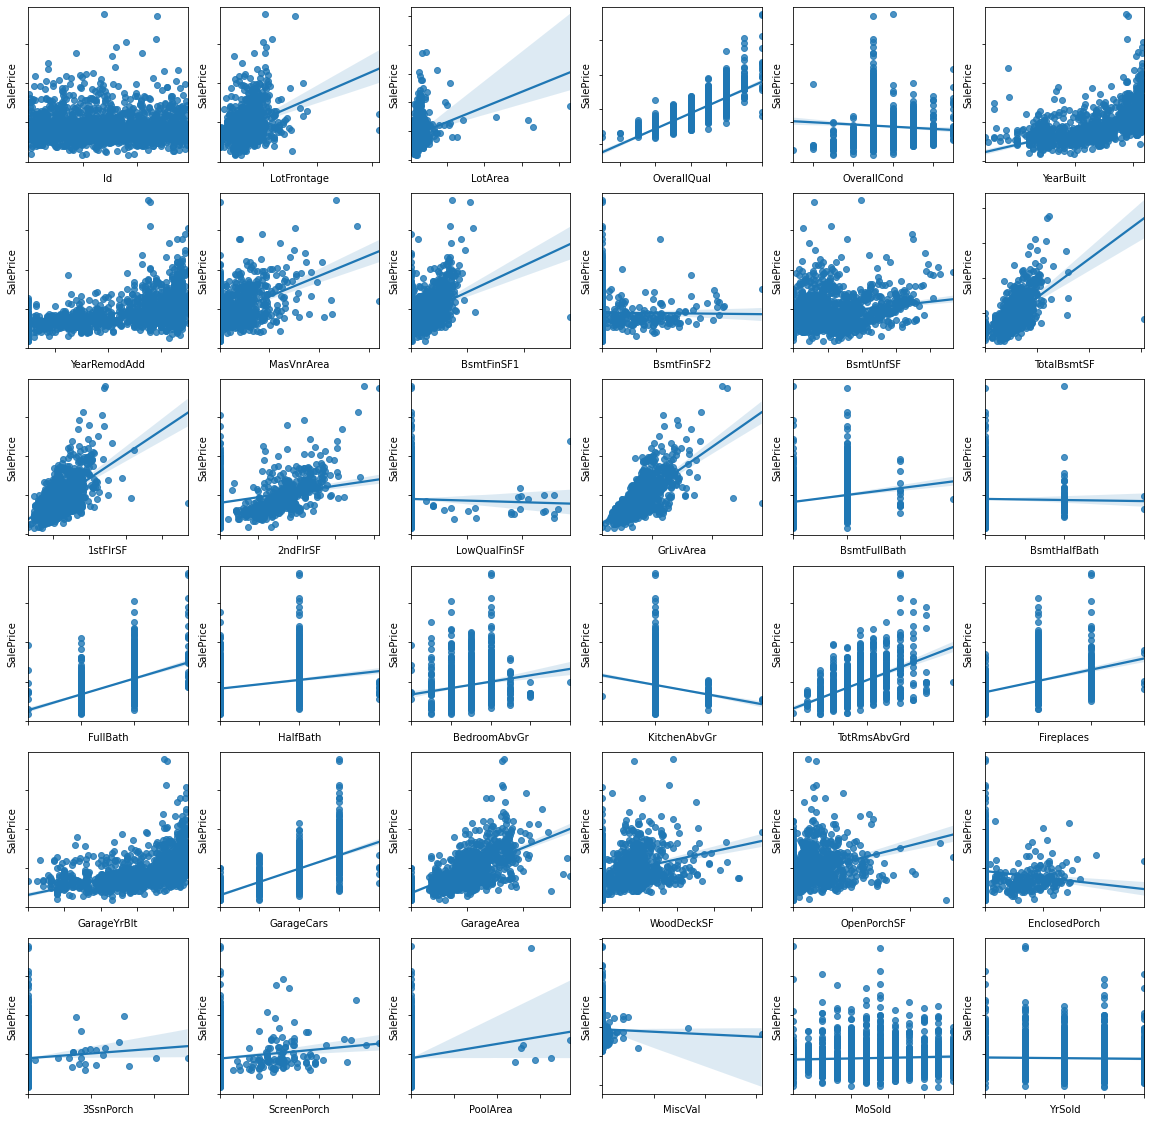

In [38]:
fig, ax = plt.subplots(6,6,figsize=(20,20))
for idx, i in enumerate(numerical_features):
    if i == 'SalePrice':
        continue
    sns.regplot(x=i, y="SalePrice", data=train, ax = ax[idx//6, idx%6])
    ax[idx//6,idx%6].set(yticklabels=[])
    ax[idx//6,idx%6].set(xticklabels=[])


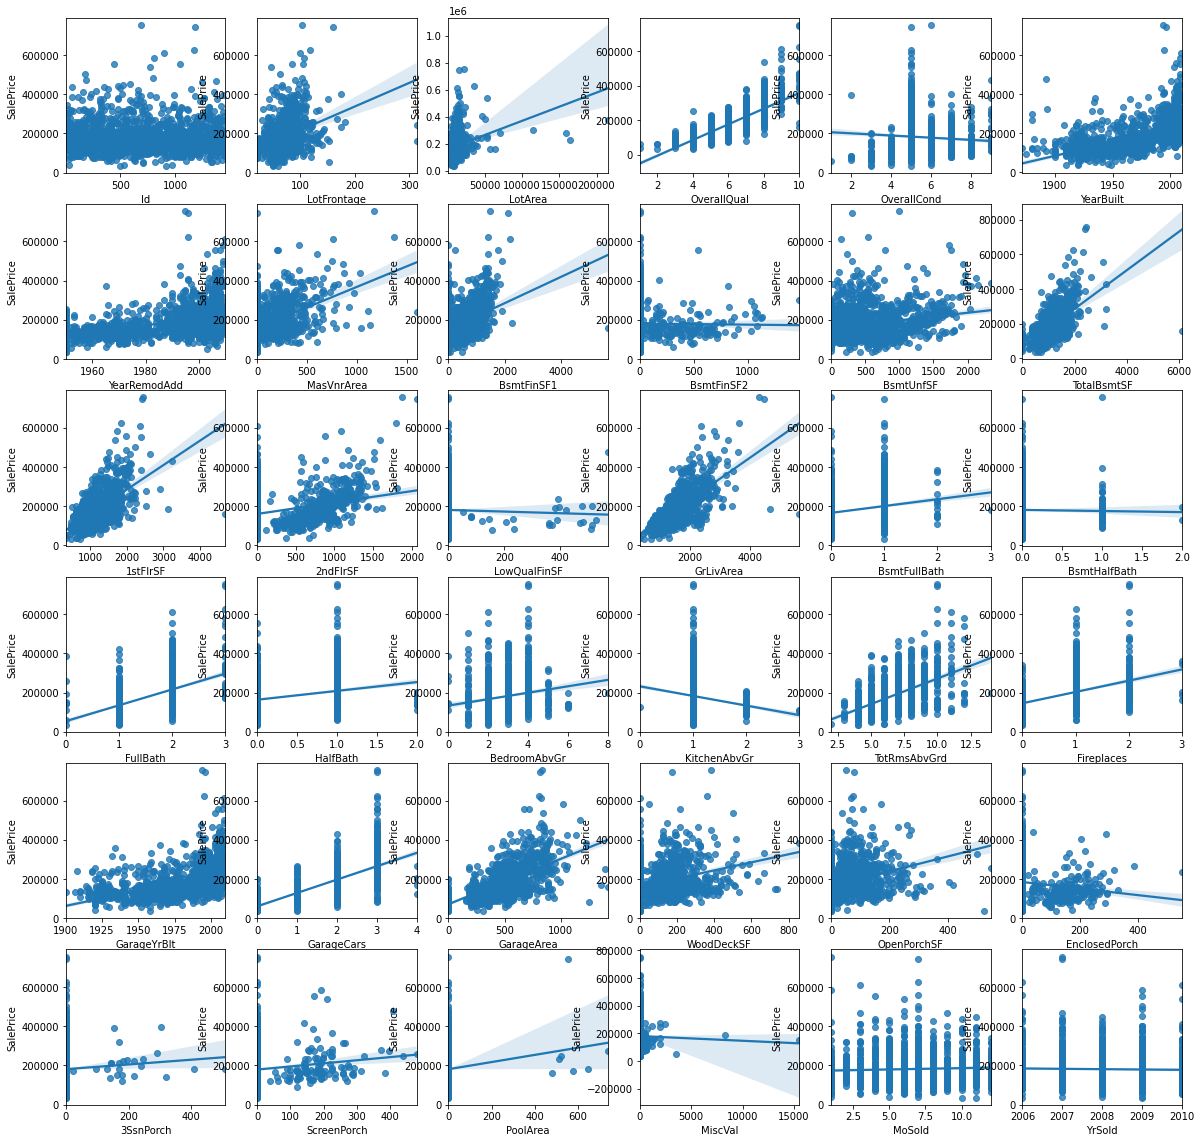

In [39]:
fig, ax = plt.subplots(6,6,figsize=(20,20))
for idx, i in enumerate(numerical_features):
    if i == 'SalePrice':
        continue
    sns.regplot(x=i, y="SalePrice", data=train, ax = ax[idx//6, idx%6])

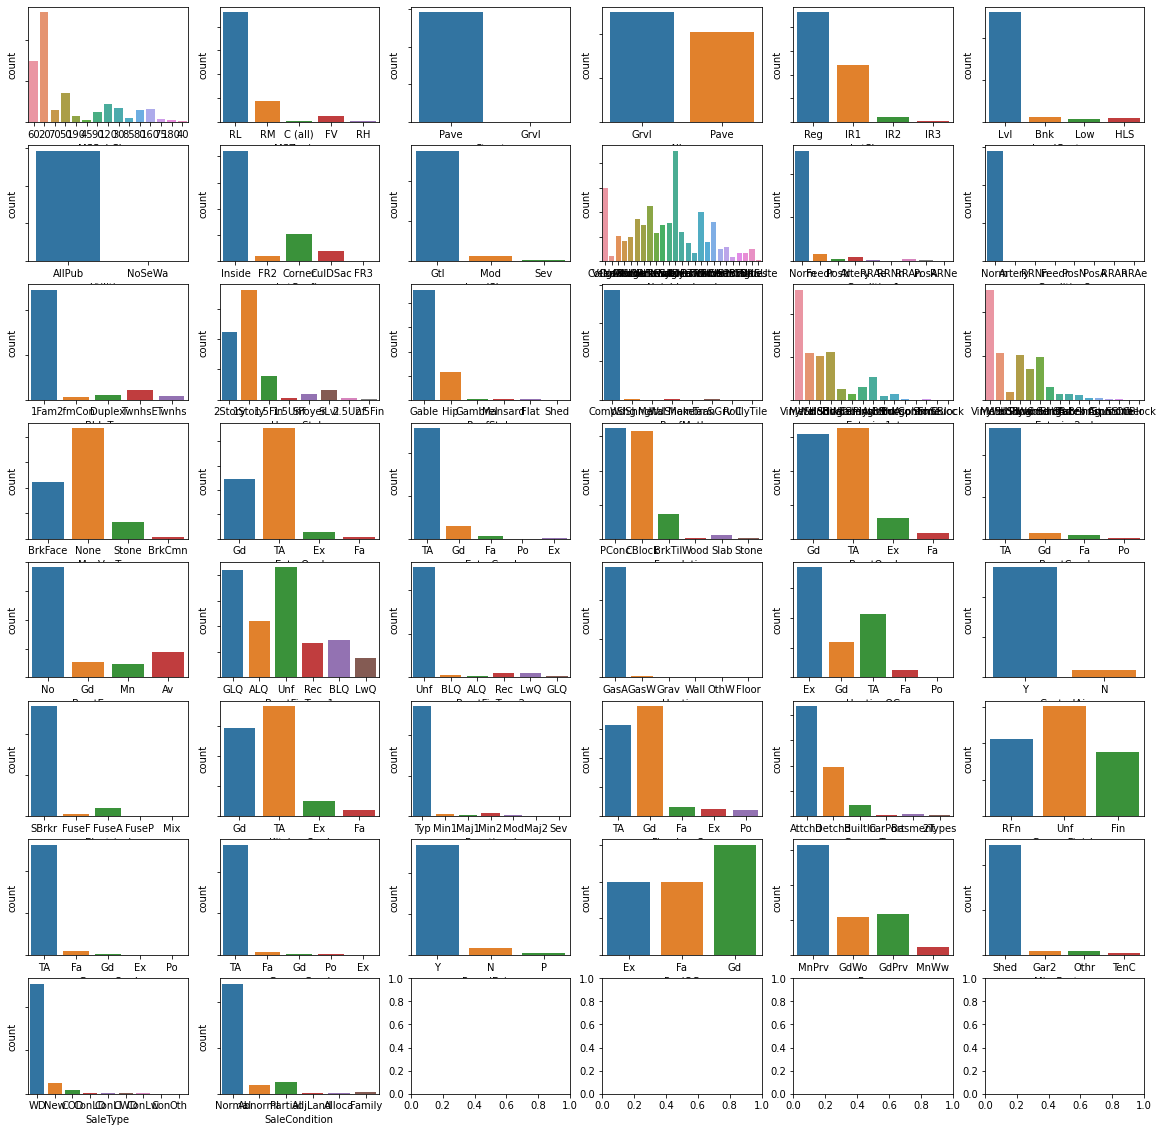

In [43]:

fig, ax = plt.subplots(8,6, figsize = (20,20))

for idx, n in enumerate(categorical_features):
    sns.countplot(x=n, data=train, ax = ax[idx//6, idx % 6])
    ax[idx//6, idx % 6].set(yticklabels=[])

In [44]:

# Make df_train set to check 2ndFloor and Basement
df_train = train.copy()


In [45]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [46]:
df_train["2ndFloor"] = "2ndFloor"


In [47]:
df_train["2ndFlrSF"]==0

0       False
1        True
2       False
3       False
4       False
        ...  
1455    False
1456     True
1457    False
1458     True
1459     True
Name: 2ndFlrSF, Length: 1460, dtype: bool

In [51]:
df_train["2ndFloor"].loc[df_train["2ndFlrSF"]==0] = "No 2ndFloor"

In [52]:
df_train["2ndFloor"]

0          2ndFloor
1       No 2ndFloor
2          2ndFloor
3          2ndFloor
4          2ndFloor
           ...     
1455       2ndFloor
1456    No 2ndFloor
1457       2ndFloor
1458    No 2ndFloor
1459    No 2ndFloor
Name: 2ndFloor, Length: 1460, dtype: object

In [ ]:
df_train["2ndFloor"] = "2ndFloor"
df_train["2ndFloor"].loc[df_train["2ndFlrSF"]==0] = "No 2ndFloor"